## Visium H&E Spatial Analysis with Squidpy

This notebook demonstrates how to use **Squidpy** for advanced spatial analysis on a **10x Genomics Visium** mouse brain coronal section stained with **H&E (Hematoxylin and Eosin)**. The dataset has already been pre-processed and includes cluster annotations generated from gene expression profiles.

H&E staining provides rich tissue morphology information:

* **Hematoxylin:** stains nuclei in blue/purple tones
* **Eosin:** stains cytoplasm and extracellular structures in pink tones

While previous fluorescence-based analysis emphasized image segmentation and marker detection, this notebook focuses on **spatial organization of tissue clusters** and how neighboring regions may biologically interact.

The main goal is to understand how transcriptomic clusters are arranged across the tissue and whether nearby clusters show coordinated behavior or communication signals.

### Objectives

By the end of this notebook, we will:

1. **Load** the Visium dataset and visualize spatial cluster distribution
2. **Extract image summary features** from the H&E histology image
3. **Construct a spatial neighbor graph** connecting nearby Visium spots
4. **Perform neighborhood enrichment analysis** to identify clusters that preferentially neighbor one another
5. **Run co-occurrence analysis** to measure how clusters associate across spatial distances
6. **Investigate ligand-receptor interactions** to explore potential cell-cell communication between adjacent clusters

This workflow highlights how spatial transcriptomics can move beyond clustering alone, revealing tissue architecture, regional interactions, and biologically meaningful communication networks within the brain.


In [1]:
!pip install scanpy squidpy igraph leidenalg scikit-image dask

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 22.4 MB/s eta 0:00:00
   ━━

INFO     Downloading visium_hne_image.tiff from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_image.tiff                                    


  0%|                                               | 0.00/398M [00:00<?, ?B/s]

INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


  0%|                                               | 0.00/329M [00:00<?, ?B/s]

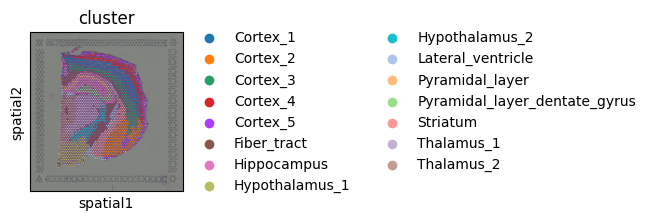

In [2]:
import scanpy as sc
import anndata as ad
import squidpy as sq
import numpy as np
import pandas as pd

img   = sq.datasets.visium_hne_image()
adata = sq.datasets.visium_hne_adata()
sq.pl.spatial_scatter(adata, color="cluster")

### Imports and Data Loading

We load the pre-processed H&E Visium dataset. `adata` contains gene
expression counts with Leiden cluster annotations. `img` holds the
H&E tissue image. We immediately visualize the cluster layout in tissue
coordinates to get an overview of the spatial structure before analysis.

In [3]:
sq.im.calculate_image_features(
    adata, img,
    features="summary",
    key_added="features_summary",
    n_jobs=1,
)

  0%|          | 0/2688 [00:00<?, ?/s]

### Image Summary Features

Even with H&E data, we can extract image-level statistics per spot —
things like mean intensity, standard deviation, and percentile values
of the pixel intensities under each spot. These "summary features"
can be used downstream to see whether tissue morphology correlates
with gene expression clusters.

In [4]:
sq.gr.spatial_neighbors(adata, coord_type="grid", n_rings=1)

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


### Building the Spatial Neighbor Graph

Before computing any spatial statistics, we need to define which spots
are neighbors of each other. For Visium data, spots sit on a regular
hexagonal grid, so we use `coord_type="grid"` and `n_rings=1` which
connects each spot to its immediate surrounding ring of spots.

The result is a connectivity matrix stored in `adata.obsp["connectivities"]`.
All subsequent spatial statistics are computed on this graph.

  0%|          | 0/1000 [00:00<?, ?/s]

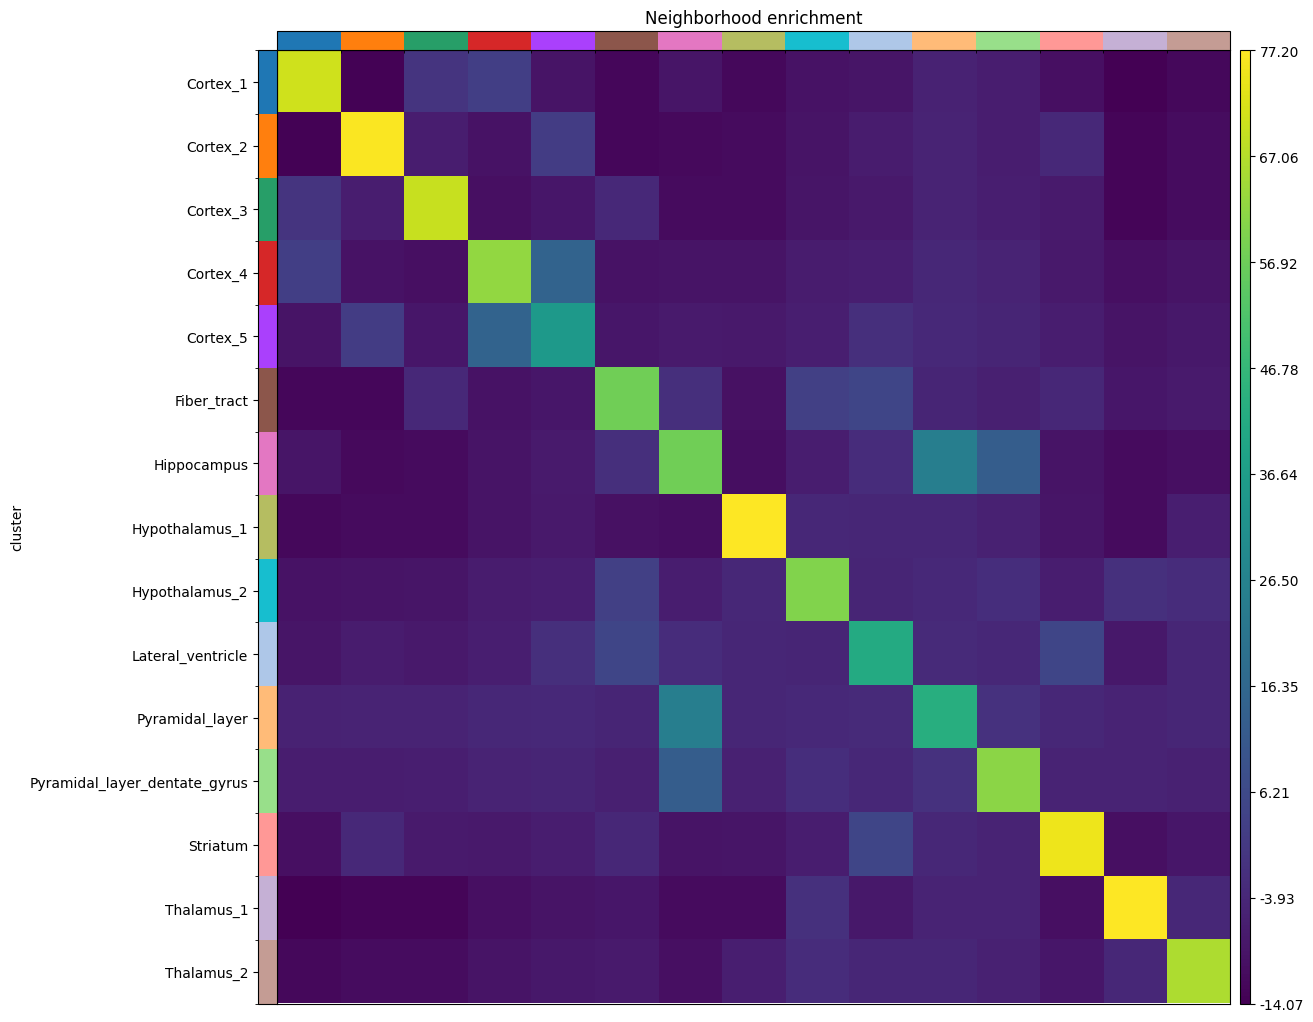

In [5]:
sq.gr.nhood_enrichment(adata, cluster_key="cluster")
sq.pl.nhood_enrichment(adata, cluster_key="cluster")

### Neighborhood Enrichment

This asks: do spots from cluster A tend to be neighbors of spots from
cluster B more than you'd expect by chance? The score is computed by
permutation — cluster labels are shuffled many times and the observed
co-adjacency is compared against the shuffled distribution.

A high positive score means two clusters are spatially enriched neighbors.
A low negative score means they tend to be spatially separated. The result
is shown as a heatmap of cluster pairs.

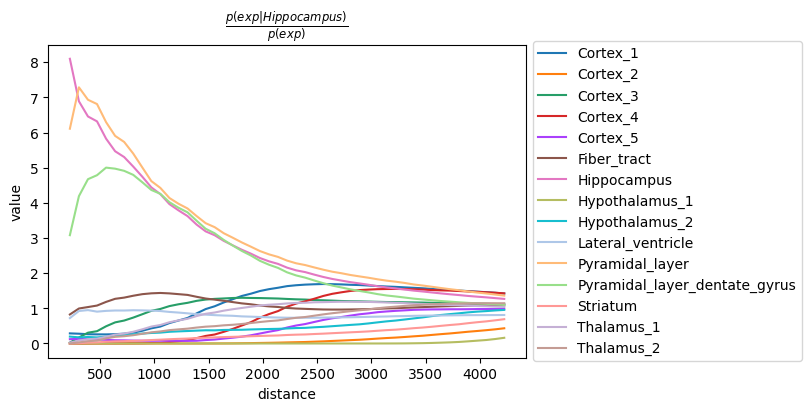

In [6]:
sq.gr.co_occurrence(adata, cluster_key="cluster")
sq.pl.co_occurrence(adata, cluster_key="cluster", clusters="Hippocampus", figsize=(8, 4))

### Co-occurrence Analysis

Co-occurrence measures how the probability of observing cluster B changes
as you move further away from a spot in cluster A, across a range of
distance bins. A ratio above 1.0 at short distances means the two clusters
tend to co-occur spatially. Ratio near 1.0 at long distances means independence.

Here we focus on the Hippocampus cluster and see which other clusters
tend to appear nearby at different spatial scales.

0.00B [00:00, ?B/s]

0.00B [00:00, ?B/s]

0.00B [00:00, ?B/s]

  0%|          | 0/100 [00:00<?, ?permutation/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_ligrec.py:248: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
  if cluster_key not in adata.uns_keys():
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_ligrec.py:36: UserWarning: Over 500 categories found. Plot would be very large.
  super().__init__(*args, **kwargs)




In [7]:
sq.gr.ligrec(adata, n_perms=100, cluster_key="cluster")
sq.pl.ligrec(
    adata,
    cluster_key="cluster",
    source_groups="Hippocampus",
    target_groups=["Pyramidal_layer_dentate_gyrus", "Pyramidal_layer"],
    means_range=(0.3, float("inf")),
    alpha=1e-4,
    swap_axes=True,
)

### Ligand-Receptor Interaction Analysis

`sq.gr.ligrec` tests whether ligand genes expressed in one cluster are
paired with matching receptor genes expressed in a spatially neighboring
cluster. This gives a hypothesis about which clusters may be communicating
via secreted signaling molecules.

We focus on the Hippocampus cluster as the source and two pyramidal layer
clusters as targets. We filter to only high-expression pairs
(`means_range=(0.3, inf)`) and only statistically significant ones
(`alpha=1e-4`). The result is a dot plot of significant ligand-receptor pairs.